<a href="https://colab.research.google.com/github/nikimajithiya83/AI_lab_experiments/blob/main/EXP_4_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras.datasets import fashion_mnist
import keras.models as models
import keras.layers as layers
from keras import regularizers
from keras.layers import Dropout

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense,Activation,Flatten,Dropout,Conv2D, MaxPooling2D, LeakyReLU
from tensorflow.keras.utils import to_categorical   #for the categorical data

In [ ]:
print(keras.__version__)

3.13.2


In [ ]:
#import the dataset #x: Images and Y: labels of the images
(train_X,train_Y),(test_X,test_Y)=fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


9


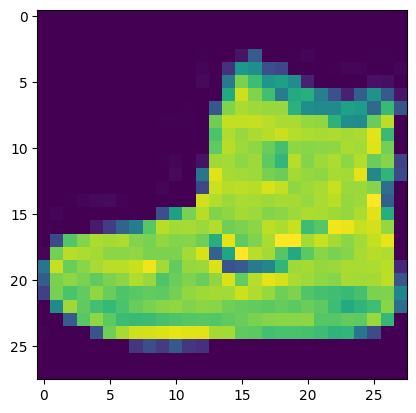

In [ ]:
plt.imshow(train_X[0])
print(train_Y[0])

In [ ]:
print(train_X.shape,train_Y.shape)

(60000, 28, 28) (60000,)


In [ ]:
print(test_X.shape, test_Y.shape)

(10000, 28, 28) (10000,)


In [ ]:
classes=np.unique(train_Y)
nClasses=len(classes)
print(classes)
print(nClasses)

[0 1 2 3 4 5 6 7 8 9]
10


In [ ]:
train_X=train_X.reshape(-1,28,28,1)
test_X=test_X.reshape(-1,28,28,1)

In [ ]:
print(train_X.shape,train_Y.shape)
print(test_X.shape, test_Y.shape)

(60000, 28, 28, 1) (60000,)
(10000, 28, 28, 1) (10000,)


In [ ]:
#Range of pixel values for each type of image
#Black-White: 0-1
#Grayscale: 0-255
#RGB: (0-255)*3

In [ ]:
#converting the values of the pixels from 0-1
#type-conversion
train_X=train_X.astype('float32')
test_X=test_X.astype('float32')
train_X=train_X/255
test_X=test_X/255

In [ ]:
train_Y_one_hot=to_categorical(train_Y)
test_Y_one_hot=to_categorical(test_Y)

In [ ]:
train_Y[0]

np.uint8(9)

In [ ]:
train_Y_one_hot[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [ ]:
#Model training task

In [ ]:
from sklearn.model_selection import train_test_split
train_X,valid_X,train_label,valid_label=train_test_split(train_X,train_Y_one_hot,test_size=0.2,random_state=13)

In [ ]:
train_X.shape,valid_X.shape,train_label.shape,valid_label.shape

((48000, 28, 28, 1), (12000, 28, 28, 1), (48000, 10), (12000, 10))

In [ ]:
#Basic CNN model Develop
#Regularization and Dropout
#2nd CNN MODEL DEVELOPMENT

In [ ]:
batch_size=64
epochs=20
num_classes=10

In [ ]:
model=tf.keras.Sequential()

In [ ]:
#1st hidden layer
model.add(tf.keras.layers.Conv2D(32,(3,3),activation="linear",padding='same'))
model.add(tf.keras.layers.LeakyReLU(alpha=0.1))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2),padding='same'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:
#2nd hidden layer
model.add(tf.keras.layers.Conv2D(64,(3,3),activation="linear",padding='same'))
model.add(tf.keras.layers.LeakyReLU(alpha=0.1))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2),padding='same'))

In [ ]:
#3rd hidden layer
model.add(tf.keras.layers.Conv2D(128,(3,3),activation="linear",padding='same'))
model.add(tf.keras.layers.LeakyReLU(alpha=0.1))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2),padding='same'))

In [ ]:
model.add(tf.keras.layers.Flatten())

In [ ]:
model.add(tf.keras.layers.Dense(128,activation='linear'))
model.add(tf.keras.layers.LeakyReLU(alpha=0.1))
model.add(tf.keras.layers.Dense(num_classes,activation='softmax'))#output final layer

In [ ]:
model.compile(loss=tf.keras.losses.categorical_crossentropy,optimizer=tf.keras.optimizers.Adam(),metrics=['accuracy'])

In [ ]:
48000/64

750.0

In [ ]:
model_train=model.fit(train_X,train_label,batch_size=64,epochs=20,verbose=1,validation_data=(valid_X,valid_label))

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 96s 124ms/step - accuracy: 0.8296 - loss: 0.4661 - val_accuracy: 0.8786 - val_loss: 0.3311
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 93s 124ms/step - accuracy: 0.8924 - loss: 0.2922 - val_accuracy: 0.8978 - val_loss: 0.2805
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 92s 123ms/step - accuracy: 0.9103 - loss: 0.2437 - val_accuracy: 0.8994 - val_loss: 0.2712
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 88s 118ms/step - accuracy: 0.9219 - loss: 0.2119 - val_accuracy: 0.9144 - val_loss: 0.2404
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 143s 119ms/step - accuracy: 0.9310 - loss: 0.1860 - val_accuracy: 0.9152 - val_loss: 0.2397
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 143s 120ms/step - accuracy: 0.9394 - loss: 0.1622 - val_accuracy: 0.9209 - val_loss: 0.2272
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 93s 124ms/step - accuracy: 0.9470 - loss: 0.1419 - val_accuracy: 0.9176 - val_loss: 0.2483
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 93s 123ms/step - accuracy: 0.9534 - loss:

In [ ]:
testing_evaluation=model.evaluate(test_X,test_Y_one_hot)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9168 - loss: 0.4511


In [ ]:
testing_evaluation  #loss,accuracy

[0.4511006474494934, 0.9168000221252441]

In [ ]:
model_train.history

{'accuracy': [0.8296250104904175,
  0.8923541903495789,
  0.9103124737739563,
  0.921875,
  0.9309791922569275,
  0.9393541812896729,
  0.9469583630561829,
  0.953416645526886,
  0.9603124856948853,
  0.9664999842643738,
  0.9729999899864197,
  0.9752500057220459,
  0.979729175567627,
  0.9816458225250244,
  0.9827083349227905,
  0.984333336353302,
  0.9853749871253967,
  0.9876875281333923,
  0.9879166483879089,
  0.9884166717529297],
 'loss': [0.4660775065422058,
  0.29217830300331116,
  0.24367296695709229,
  0.21187657117843628,
  0.186028853058815,
  0.16218067705631256,
  0.14191333949565887,
  0.12322250008583069,
  0.10449963063001633,
  0.08819718658924103,
  0.07272771000862122,
  0.06533482670783997,
  0.05401838198304176,
  0.047299448400735855,
  0.04555675759911537,
  0.04178304970264435,
  0.03879866376519203,
  0.03379786014556885,
  0.03305397182703018,
  0.031680766493082047],
 'val_accuracy': [0.8785833120346069,
  0.8977500200271606,
  0.8994166851043701,
  0.914416

In [ ]:
accuracy=model_train.history['accuracy']
val_accuracy=model_train.history['val_accuracy']
loss=model_train.history['loss']
val_loss=model_train.history['val_loss']
epochs=range(len(accuracy))

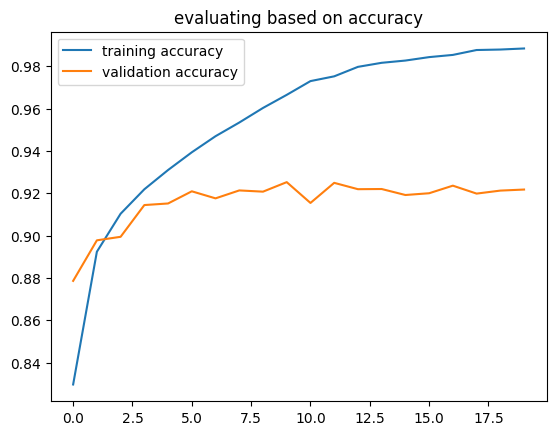

In [ ]:
plt.plot(epochs,accuracy,label='training accuracy')
plt.plot(epochs,val_accuracy,label='validation accuracy')
plt.title('evaluating based on accuracy')
plt.legend()
plt.show()

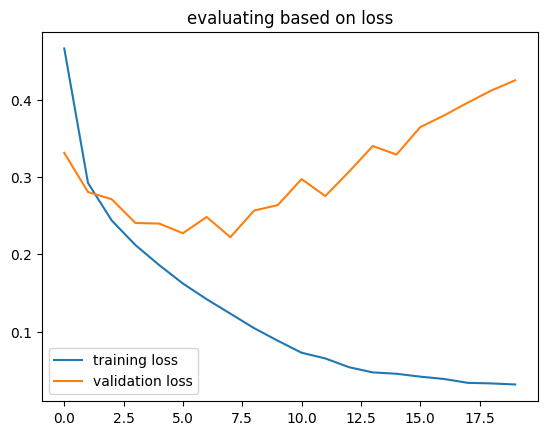

In [ ]:
plt.plot(epochs,loss,label='training loss')
plt.plot(epochs,val_loss,label='validation loss')
plt.title('evaluating based on loss')
plt.legend()
plt.show()

Regularization

In [ ]:
regmodel=tf.keras.Sequential()
#1st hidden layer
regmodel.add(tf.keras.layers.Conv2D(32,(3,3),activation="linear",padding='same'))
regmodel.add(tf.keras.layers.LeakyReLU(alpha=0.1))
regmodel.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2),padding='same'))
regmodel.add(tf.keras.layers.Dropout(0.25))
#2nd hidden layer
regmodel.add(tf.keras.layers.Conv2D(64,(3,3),activation="linear",padding='same'))
regmodel.add(tf.keras.layers.LeakyReLU(alpha=0.1))
regmodel.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2),padding='same'))
regmodel.add(tf.keras.layers.Dropout(0.25))
#3rd hidden layer
regmodel.add(tf.keras.layers.Conv2D(128,(3,3),activation="linear",padding='same'))
regmodel.add(tf.keras.layers.LeakyReLU(alpha=0.1))
regmodel.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2),padding='same'))
regmodel.add(tf.keras.layers.Dropout(0.40))

regmodel.add(tf.keras.layers.Flatten())
regmodel.add(tf.keras.layers.Dense(128,activation='linear'))
regmodel.add(tf.keras.layers.LeakyReLU(alpha=0.1))
regmodel.add(tf.keras.layers.Dropout(0.3))
regmodel.add(tf.keras.layers.Dense(num_classes,activation='softmax'))#output final layer

In [ ]:
regmodel.compile(loss=tf.keras.losses.categorical_crossentropy,optimizer=tf.keras.optimizers.Adam(),metrics=['accuracy'])

In [ ]:
reg_model_train=regmodel.fit(train_X,train_label,batch_size=64,epochs=20,verbose=1,validation_data=(valid_X,valid_label))

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 97s 126ms/step - accuracy: 0.7759 - loss: 0.6051 - val_accuracy: 0.8702 - val_loss: 0.3596
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 142s 126ms/step - accuracy: 0.8618 - loss: 0.3756 - val_accuracy: 0.8837 - val_loss: 0.3105
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 99s 132ms/step - accuracy: 0.8815 - loss: 0.3253 - val_accuracy: 0.8968 - val_loss: 0.2764
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 137s 125ms/step - accuracy: 0.8902 - loss: 0.2968 - val_accuracy: 0.9030 - val_loss: 0.2604
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 146s 131ms/step - accuracy: 0.8940 - loss: 0.2807 - val_accuracy: 0.9054 - val_loss: 0.2571
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 99s 131ms/step - accuracy: 0.9008 - loss: 0.2648 - val_accuracy: 0.9114 - val_loss: 0.2371
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 138s 126ms/step - accuracy: 0.9044 - loss: 0.2545 - val_accuracy: 0.9125 - val_loss: 0.2353
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 94s 126ms/step - accuracy: 0.9073 - los